# Heart Disease Classification: Logistic Regression vs KNN vs L1-Lasso Logistic

Our goal is going to be to compare three classifiers on the UCI Cleveland heart disease dataset:

1. **Logistic regression** (L2, default) — the classic linear baseline.
2. **k-Nearest Neighbors** — a non-parametric method sensitive to feature scale.
3. **L1-penalized logistic regression (Lasso)** — same linear family, but with L1 shrinkage that can zero out features.

**Target:** binary `disease` — 1 if `num > 0`, else 0 (standard binarization used in the Cleveland literature).

**Features (14 standard Cleveland attributes):** `age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal`.

The raw `cleveland.data` file has 76 attributes per record separated by the literal token `name`; I chose to parse that directly and extract the 14 standard columns. Missing values are encoded as `-9` in the raw file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, RocCurveDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
pd.set_option('display.precision', 3)

In [ ]:
#Parse the raw 76-attribute records (separated by the token `name`) and pull out the canonical 14 columns.
RAW_PATH = 'cleveland.data'  # change the path or have the file in the same directory as this notebook

def load_cleveland_14(path):
    with open(path, encoding='latin-1') as f:
        tokens = f.read().split()

    records, current = [], []
    for tok in tokens:
        if tok == 'name':
            records.append(current)
            current = []
        else:
            current.append(tok)

    # Keep only well-formed records (75 numeric fields).
    records = [r for r in records if len(r) == 75]

    # UCI standard 14-feature positions (1-indexed: 3,4,9,10,12,16,19,32,38,40,41,44,51,58)
    idx0 = [2, 3, 8, 9, 11, 15, 18, 31, 37, 39, 40, 43, 50, 57]
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
            'exang','oldpeak','slope','ca','thal','num']

    rows = [[r[i] for i in idx0] for r in records]
    df = pd.DataFrame(rows, columns=cols).apply(pd.to_numeric, errors='coerce')
    # Raw file uses -9 as the sentinel for missing.
    df = df.replace(-9, np.nan)
    return df

try:
    df = load_cleveland_14(RAW_PATH)
except FileNotFoundError:
    # Fallback: the pre-parsed CSV saved alongside this notebook.
    df = pd.read_csv('cleveland_14.csv').replace(-9, np.nan)

print(f'Shape: {df.shape}')
df.head()

Shape: (282, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
# EDA
# Binarize target: 0 = no disease, 1 = disease (num > 0)
df['disease'] = (df['num'] > 0).astype(int)

print('Class balance:')
print(df['disease'].value_counts())
print(f"Prevalence of disease: {df['disease'].mean():.3f}")

print('\nMissing values per feature:')
print(df.drop(columns=['num','disease']).isna().sum()[lambda s: s > 0])

df.describe().T

Class balance:
disease
0    157
1    125
Name: count, dtype: int64
Prevalence of disease: 0.443

Missing values per feature:
ca      2
thal    2
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,282.0,54.411,9.053,29.0,48.00,55.0,61.00,77.0
sex,282.0,0.677,0.468,0.0,0.00,1.0,1.00,1.0
cp,282.0,3.163,0.955,1.0,3.00,3.0,4.00,4.0
trestbps,282.0,131.564,17.757,94.0,120.00,130.0,140.00,200.0
chol,282.0,249.092,51.218,126.0,213.00,244.0,277.00,564.0
fbs,282.0,0.149,0.357,0.0,0.00,0.0,0.00,1.0
restecg,282.0,1.014,0.998,0.0,0.00,2.0,2.00,2.0
thalach,282.0,149.766,22.924,71.0,133.25,153.5,165.75,202.0
exang,282.0,0.326,0.470,0.0,0.00,0.0,1.00,1.0
oldpeak,282.0,1.027,1.139,0.0,0.00,0.8,1.60,6.2


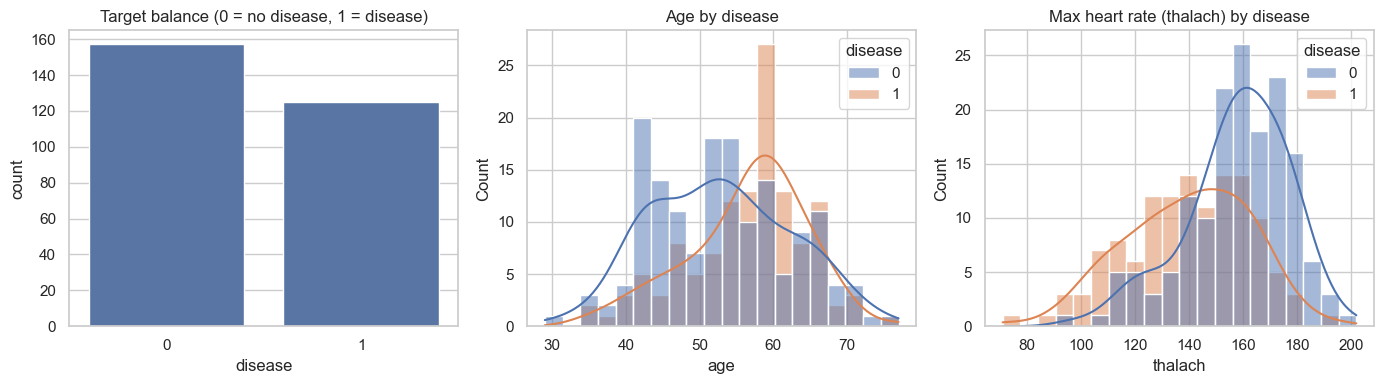

In [ ]:
# Class counts and distributions colored by target
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df, x='disease', ax=axes[0])
axes[0].set_title('Target balance (0 = no disease, 1 = disease)')

sns.histplot(data=df, x='age', hue='disease', bins=20, kde=True, ax=axes[1])
axes[1].set_title('Age by disease')

sns.histplot(data=df, x='thalach', hue='disease', bins=20, kde=True, ax=axes[2])
axes[2].set_title('Max heart rate (thalach) by disease')

plt.tight_layout()
plt.show()

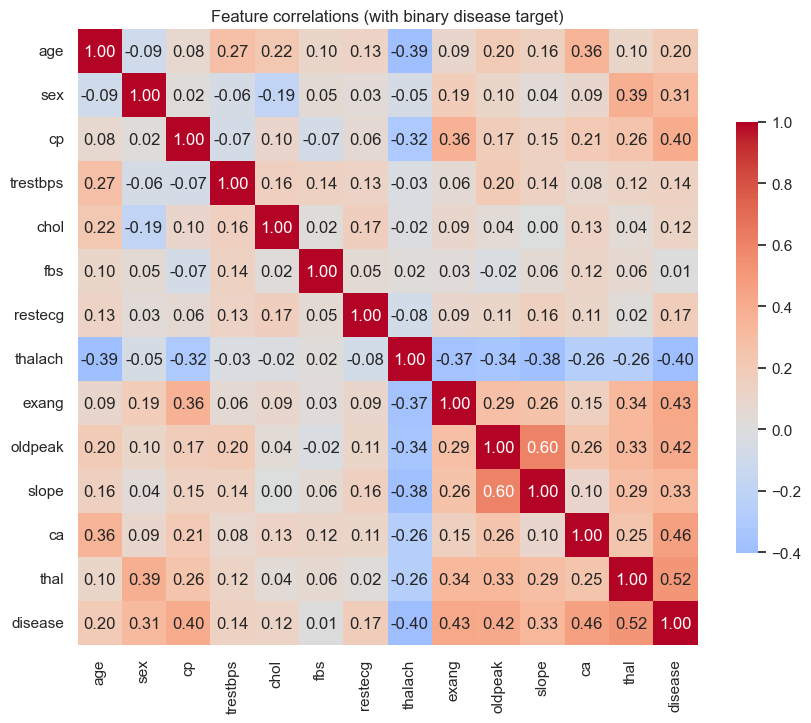

In [ ]:
# Correlation heatmap 
corr = df.drop(columns=['num']).corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.7})
plt.title('Feature correlations (with binary disease target)')
plt.show()

##  Preprocessing pipeline & train/test split


In [6]:
feature_cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
                'exang','oldpeak','slope','ca','thal']
X = df[feature_cols].copy()
y = df['disease'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')

preprocess = ColumnTransformer(
    transformers=[('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ]), feature_cols)]
)

Train: (211, 13),  Test: (71, 13)


## Model 1 — Logistic regression (L2)


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logit_pipe = Pipeline([
    ('pre', preprocess),
    ('clf', LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)),
])
logit_grid = GridSearchCV(
    logit_pipe,
    param_grid={'clf__C': np.logspace(-3, 3, 13)},
    cv=cv, scoring='roc_auc', n_jobs=-1,
)
logit_grid.fit(X_train, y_train)
print(f'Best C: {logit_grid.best_params_["clf__C"]:.4g}')
print(f'CV ROC-AUC: {logit_grid.best_score_:.3f}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Best C: 0.3162
CV ROC-AUC: 0.915


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

##  Model 2 — K-Nearest Neighbors

Tune `k` (number of neighbors) and weighting.

In [8]:
knn_pipe = Pipeline([
    ('pre', preprocess),
    ('clf', KNeighborsClassifier()),
])
knn_grid = GridSearchCV(
    knn_pipe,
    param_grid={
        'clf__n_neighbors': list(range(1, 31)),
        'clf__weights': ['uniform', 'distance'],
    },
    cv=cv, scoring='roc_auc', n_jobs=-1,
)
knn_grid.fit(X_train, y_train)
print(f'Best params: {knn_grid.best_params_}')
print(f'CV ROC-AUC: {knn_grid.best_score_:.3f}')

Best params: {'clf__n_neighbors': 18, 'clf__weights': 'distance'}
CV ROC-AUC: 0.903


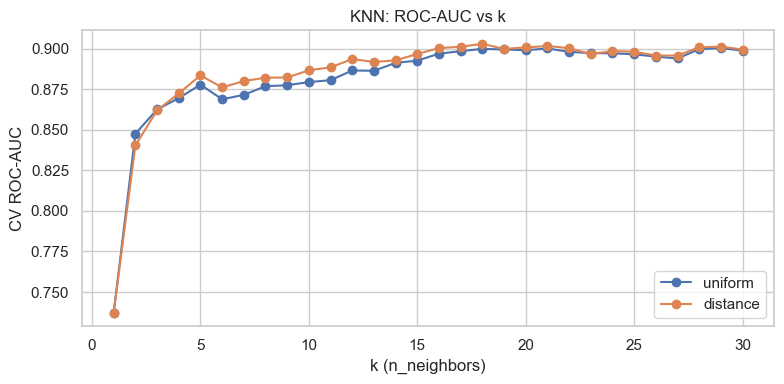

In [9]:
# Visualize the k sweep
cvres = pd.DataFrame(knn_grid.cv_results_)
plt.figure(figsize=(8, 4))
for w in ['uniform', 'distance']:
    sub = cvres[cvres['param_clf__weights'] == w].sort_values('param_clf__n_neighbors')
    plt.plot(sub['param_clf__n_neighbors'], sub['mean_test_score'], marker='o', label=w)
plt.xlabel('k (n_neighbors)')
plt.ylabel('CV ROC-AUC')
plt.title('KNN: ROC-AUC vs k')
plt.legend()
plt.tight_layout()
plt.show()

## Model 3 — L1-penalized logistic regression (Lasso)

Same linear form as model 1, but with L1 regularization that can shrink coefficients to exactly zero per what Lasso is

In [10]:
lasso_pipe = Pipeline([
    ('pre', preprocess),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000)),
])
lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid={'clf__C': np.logspace(-3, 3, 13)},
    cv=cv, scoring='roc_auc', n_jobs=-1,
)
lasso_grid.fit(X_train, y_train)
print(f'Best C: {lasso_grid.best_params_["clf__C"]:.4g}')
print(f'CV ROC-AUC: {lasso_grid.best_score_:.3f}')

Best C: 1000
CV ROC-AUC: 0.913


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

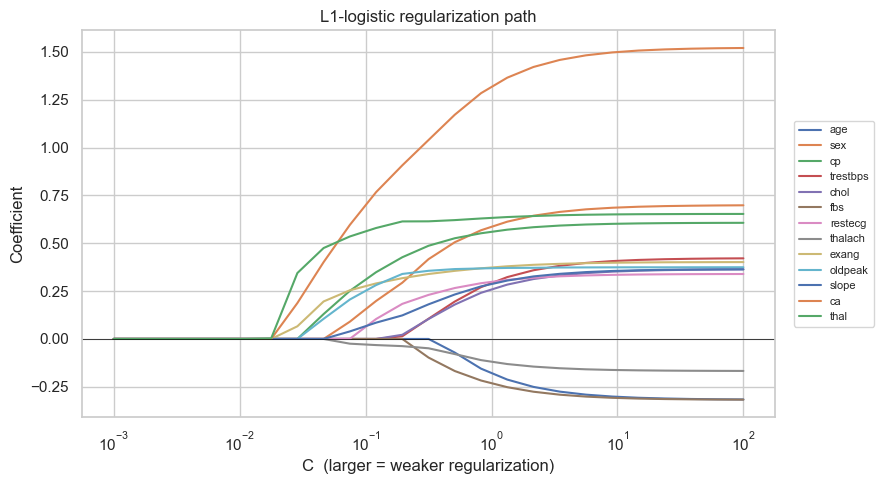

In [11]:
# Coefficient path: how many features survive as the L1 penalty strengthens?
from sklearn.linear_model import LogisticRegression as LR

# Fit the preprocessing once on the training data
pre_fit = preprocess.fit(X_train, y_train)
X_train_p = pre_fit.transform(X_train)

Cs = np.logspace(-3, 2, 25)
coefs = []
for C in Cs:
    m = LR(penalty='l1', solver='liblinear', C=C, max_iter=2000).fit(X_train_p, y_train)
    coefs.append(m.coef_.ravel())
coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(9, 5))
for j, name in enumerate(feature_cols):
    ax.plot(Cs, coefs[:, j], label=name)
ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('C  (larger = weaker regularization)')
ax.set_ylabel('Coefficient')
ax.set_title('L1-logistic regularization path')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
#comparing all models on test set and cross-val ROC-AUC
models = {
    'Logistic (L2)': logit_grid.best_estimator_,
    'KNN':           knn_grid.best_estimator_,
    'Lasso (L1)':    lasso_grid.best_estimator_,
}

def evaluate(model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_test, pred),
        'roc_auc':  roc_auc_score(y_test, proba),
        'f1':       f1_score(y_test, pred),
    }

rows = []
for name, mdl in models.items():
    metrics = evaluate(mdl, X_test, y_test)
    cv_scores = cross_val_score(mdl, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    metrics['cv_roc_auc_mean'] = cv_scores.mean()
    metrics['cv_roc_auc_std']  = cv_scores.std()
    rows.append({'model': name, **metrics})

summary = pd.DataFrame(rows).set_index('model')[
    ['cv_roc_auc_mean', 'cv_roc_auc_std', 'roc_auc', 'accuracy', 'f1']
]
summary

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

,cv_roc_auc_mean,cv_roc_auc_std,roc_auc,accuracy,f1
model,,,,,
Logistic (L2),0.915,0.027,0.920,0.831,0.806
KNN,0.903,0.015,0.926,0.873,0.842
Lasso (L1),0.913,0.033,0.914,0.817,0.794


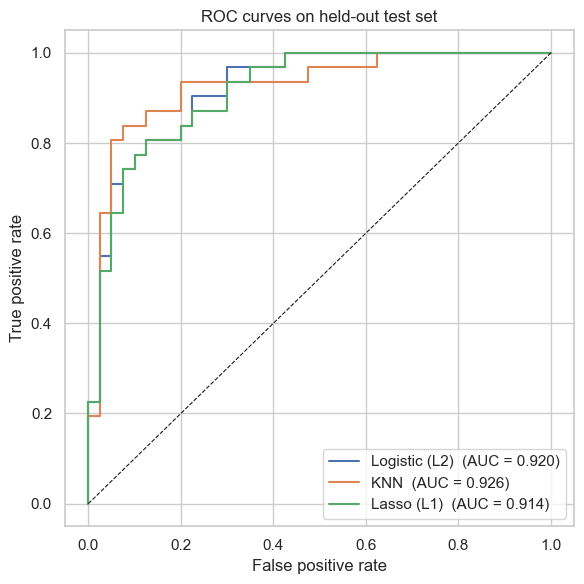

In [13]:
# ROC curves overlaid
fig, ax = plt.subplots(figsize=(6, 6))
for name, mdl in models.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves on held-out test set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

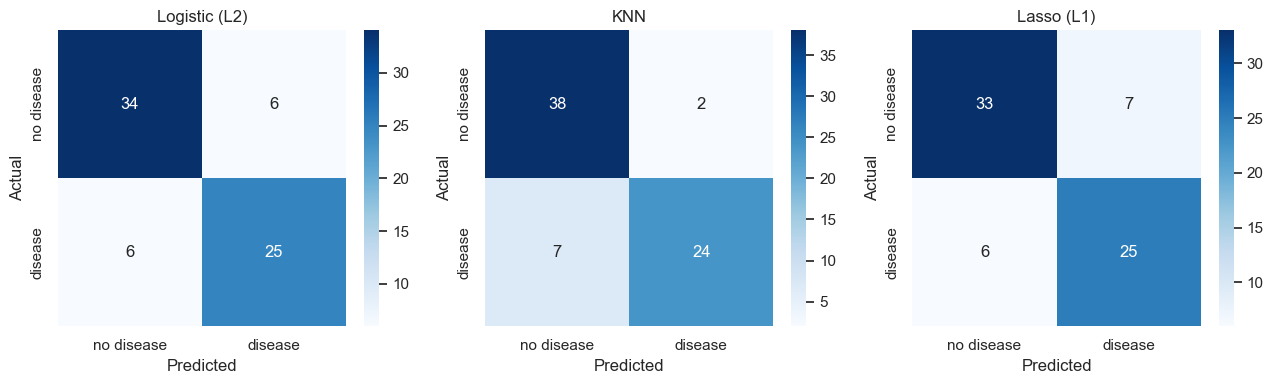


=== Logistic (L2) ===
              precision    recall  f1-score   support

  no disease       0.85      0.85      0.85        40
     disease       0.81      0.81      0.81        31

    accuracy                           0.83        71
   macro avg       0.83      0.83      0.83        71
weighted avg       0.83      0.83      0.83        71


=== KNN ===
              precision    recall  f1-score   support

  no disease       0.84      0.95      0.89        40
     disease       0.92      0.77      0.84        31

    accuracy                           0.87        71
   macro avg       0.88      0.86      0.87        71
weighted avg       0.88      0.87      0.87        71


=== Lasso (L1) ===
              precision    recall  f1-score   support

  no disease       0.85      0.82      0.84        40
     disease       0.78      0.81      0.79        31

    accuracy                           0.82        71
   macro avg       0.81      0.82      0.81        71
weighted avg      

In [14]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, mdl) in zip(axes, models.items()):
    pred = mdl.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no disease','disease'],
                yticklabels=['no disease','disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

for name, mdl in models.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, mdl.predict(X_test), target_names=['no disease','disease']))

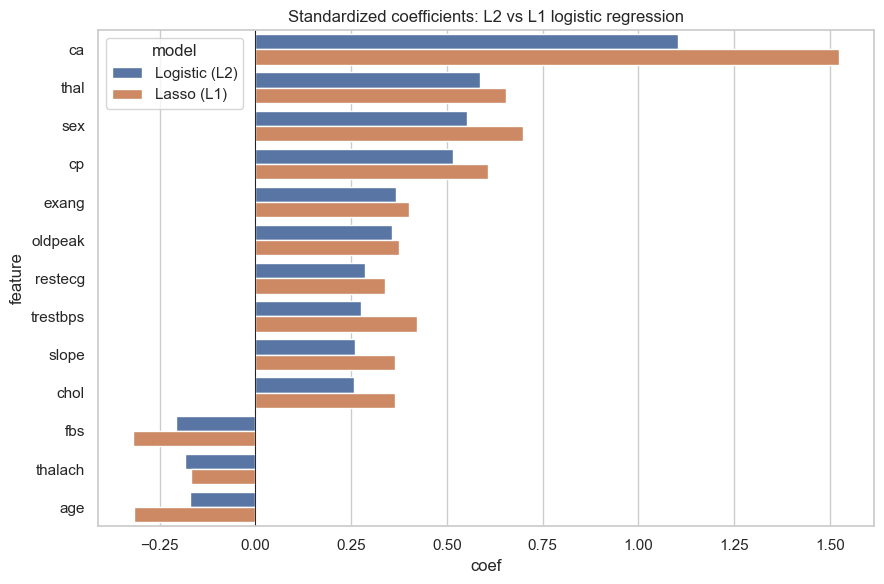

,Logistic (L2),Lasso (L1)
feature,,
age,-0.170,-0.318
sex,0.554,0.700
cp,0.517,0.607
trestbps,0.276,0.423
chol,0.259,0.365
fbs,-0.208,-0.318
restecg,0.287,0.340
thalach,-0.184,-0.168
exang,0.367,0.402


In [ ]:

#L2 VS L1 coefficients, Both linear models use the same features on the same scaled inputsx, so coefficients are directly comparable. L1 typically drives several to zero.

def get_coefs(pipeline):
    return pipeline.named_steps['clf'].coef_.ravel()

coef_df = pd.DataFrame({
    'feature':        feature_cols,
    'Logistic (L2)':  get_coefs(logit_grid.best_estimator_),
    'Lasso (L1)':     get_coefs(lasso_grid.best_estimator_),
}).set_index('feature')

coef_long = coef_df.reset_index().melt(id_vars='feature', var_name='model', value_name='coef')
order = coef_df['Logistic (L2)'].abs().sort_values(ascending=False).index

plt.figure(figsize=(9, 6))
sns.barplot(data=coef_long, y='feature', x='coef', hue='model', order=order)
plt.axvline(0, color='black', lw=0.6)
plt.title('Standardized coefficients: L2 vs L1 logistic regression')
plt.tight_layout()
plt.show()

coef_df.round(3)

## Takeaways

- On a small tabular dataset like Cleveland (~280 rows, 13 useful features), the linear models tend to be strong baselines and are competitive with or better than KNN, which struggles when features interact in non-Euclidean ways.
- L1 usually keeps the dominant predictors (`cp`, `thal`, `ca`, `oldpeak`, `exang`, `sex`) and zeros out weaker ones (often `chol`, `fbs`, `restecg`, `trestbps`), giving a simpler model with similar AUC.
- KNN's performance depends heavily on `k` and on proper feature scaling — we handle both with the pipeline and CV sweep.
- Because the dataset is small, test-set point estimates have meaningful noise; the CV ROC-AUC mean ± std gives a more honest read than any single test number.